In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display


: 

# Wczytywanie danych


In [289]:
data = np.loadtxt("dane.data", dtype=str)
data = np.char.replace(data, ',', '.').astype(float)
data_size = data.shape[0]
np.random.shuffle(data)

data_x = data[:, :8]
data_y = data[:, 8:]

# Skalowanie danych


In [290]:
#Standaryzacja
data_stand = np.empty_like(data_x)
for i in range(data_x.shape[1]):
    mean = data_x[:int(0.6 * data_size), i].mean()
    std = data_x[:int(0.6 * data_size), i].std()
    data_stand[:, i] = (data_x[:, i ] - mean) / std

# min-max
data_minmax = np.empty_like(data_x)
for i in range(data_x.shape[1]):
    mean = data_x[:int(0.6 * data_size), i].mean()
    max_v = data_x[:int(0.6 * data_size), i].max()
    min_v = data_x[:int(0.6 * data_size), i].min()
    data_minmax[:, i] = (data_x[:, i] - mean) / (max_v - min_v)

scaling_method = "standard"

match scaling_method:
    case "standard":
        data_x = data_stand
    case "minmax":
        data_x = data_minmax


# Podział danych na zbiory


In [291]:
x_train = data_x[:int(0.6 * data_size)]
y_train = data_y[:int(0.6 * data_size)]

x_test = data_x[int(0.6 * data_size) : int(0.8 * data_size)]
y_test = data_y[int(0.6 * data_size) : int(0.8 * data_size)]

x_validate = data_x[:int(0.8 * data_size)]
y_validate = data_y[:int(0.8 * data_size)]

# Regularyzacja


In [292]:

def regularization(phi, lambda1, lambda2):
    return lambda1 * np.sum(np.abs(phi)) + lambda2 * np.sum(phi**2)


def regularization_gradient(phi, lambda1, lambda2):
    return lambda1 * np.sign(phi) + 2 * lambda2 * phi

# Gradient descent

In [293]:
def model(x, phi):
    return x @ phi
def square_loss(x, phi , y, lambda1, lambda2):
    y_pred = model(x, phi)
    return np.mean((y_pred - y)**2, 0) + regularization(phi, lambda1, lambda2)



In [294]:
def compute_gradient(x, phi, y, lambda1, lambda2):
    y_pred = model(x, phi)
    gradient = x.reshape(-1,1) * (y_pred - y) + regularization_gradient(phi, lambda1, lambda2)
    return gradient 
             

In [295]:
def gradient_descent(
                    x_test, y_test, x_train, y_train,
                     phi,
                     loss_function, gradient_function,
                     learning_rate, epochs, batch_size, lambda1, lambda2,
                     learning_rate_decay, verbose=True
                     ):
    MSE_history = []
    for epoch in range(epochs):
        perm = np.random.permutation(x_train.shape[0])
        x_train = x_train[perm]
        y_train = y_train[perm]
        gradient = np.zeros_like(phi)
        for i in range(x_train.shape[0]):
            gradient += gradient_function(x_train[i], phi, y_train[i], lambda1, lambda2)
            if (i+1) % batch_size == 0:
                phi -= gradient * learning_rate/batch_size

                gradient = np.zeros_like(phi)
        remaining = x_train.shape[0] % batch_size
        if remaining > 0:
            phi -= gradient * learning_rate / remaining
        learning_rate *= learning_rate_decay
        MSE = loss_function(x_test, phi, y_test, lambda1, lambda2)
        MSE_history.append(MSE[0])
        if verbose:
            print(f"MSE after epoch {epoch + 1}: {MSE}")
    return MSE_history


# Funkcje bazowe

In [296]:
def exp_base_function(x):
    return np.exp(-x**2)
def sigmoid_base_function(x):
    return 1 / (1 + np.exp(-x))
def sqrt_base_function(x):
    return np.sqrt(np.abs(x))
def polynomial_1(x):
    return x
def polynomial_2(x):
    return np.concatenate([x, x**2], axis=1)
def polynomial_3(x):
    return np.concatenate([x, x**2, x**3], axis=1)
def polynomial_4(x):
    return np.concatenate([x, x**2, x**3, x**4], axis=1)
def polynomial_5(x):
    return np.concatenate([x, x**2, x**3, x**4, x**5], axis=1)
def polynomial_6(x):
    return np.concatenate([x, x**2, x**3, x**4, x**5, x**6], axis=1)
def polynomial_7(x):
    return np.concatenate([x, x**2, x**3, x**4, x**5, x**6, x**7], axis=1)
def polynomial_8(x):
    return np.concatenate([x, x**2, x**3, x**4, x**5, x**6, x**7, x**8], axis=1)

def polynomial_mix(x):
    return np.concatenate([x,
                           (x[:, 1] * x[:, 2]).reshape(-1, 1),
                           (x[:, 3] * x[:, 4]).reshape(-1, 1)],
                          axis=1)

base_functions = [exp_base_function, sigmoid_base_function, sqrt_base_function, polynomial_1, polynomial_2, 
                  polynomial_3, polynomial_4, polynomial_5, polynomial_6, polynomial_7, polynomial_8, polynomial_mix]

# Badanie rozwiązania analitycznego

In [297]:
def analytical_solution(x,y):
    return np.linalg.pinv(x.T @ x) @ x.T @ y
def analytical_solution_l2(x,y, lambda2):
    return np.linalg.pinv(x.T @ x + lambda2 * np.eye(x.shape[1])) @ x.T @ y

In [298]:
MSE_history= [[], []]
for base_function in base_functions:
    phi = analytical_solution(base_function(x_train), y_train)
    MSE_validate= square_loss(base_function(x_validate), phi, y_validate, 0, 0)
    MSE_history[0].append(base_function.__name__)
    MSE_history[1].append(MSE_validate[0])
    
results = pd.DataFrame({"MSE": MSE_history[1]}, index=MSE_history[0])
results.index.name = "Base function"
styled_results = results.style.set_caption("Validation MSE by base function").format("{:.4f}")
display(styled_results)




,MSE
Base function,
exp_base_function,17087.6286
sigmoid_base_function,10796.3251
sqrt_base_function,16026.4879
polynomial_1,53517.8112
polynomial_2,13261.4961
polynomial_3,12973.1859
polynomial_4,7439.1539
polynomial_5,3187.0820
polynomial_6,1558.7506


# Optymalizacja parametru lambda dla regularyzacji l2


In [299]:
base_functions = [polynomial_1,exp_base_function, sqrt_base_function, sigmoid_base_function, polynomial_6]
lambdas = [0, 0.001, 0.01, 0.1, 1,]
MSE_history= [[] for _ in lambdas]
for lambda2 in lambdas:
    for base_function in base_functions:
        phi = analytical_solution_l2(base_function(x_train), y_train, lambda2)
        MSE_validate = square_loss(base_function(x_validate), phi, y_validate, 0, lambda2)
        MSE_history[lambdas.index(lambda2)].append(MSE_validate[0])
results = pd.DataFrame(MSE_history, columns=[f"{base_function.__name__}" for base_function in base_functions], index=[f"lambda={lambda2}" for lambda2 in lambdas])
results.index.name = "Lambda"
styled_results = results.style.set_caption("Validation MSE by base function and lambda").format("{:.4f}")
display(styled_results)



,polynomial_1,exp_base_function,sqrt_base_function,sigmoid_base_function,polynomial_6
Lambda,,,,,
lambda=0,53517.8112,17087.6286,16026.4879,10796.3251,1558.7506
lambda=0.001,53521.9874,17109.9479,16035.1657,10912.6464,527524.3666
lambda=0.01,53559.5730,17310.8210,16113.2660,11959.4836,4149144.5912
lambda=0.1,53935.4214,19319.4922,16894.2275,22422.5083,9263133.9800
lambda=1,57693.1468,39400.2366,24699.7579,126521.9255,2863713.7146


# Gradient Descent z Regularyzacją


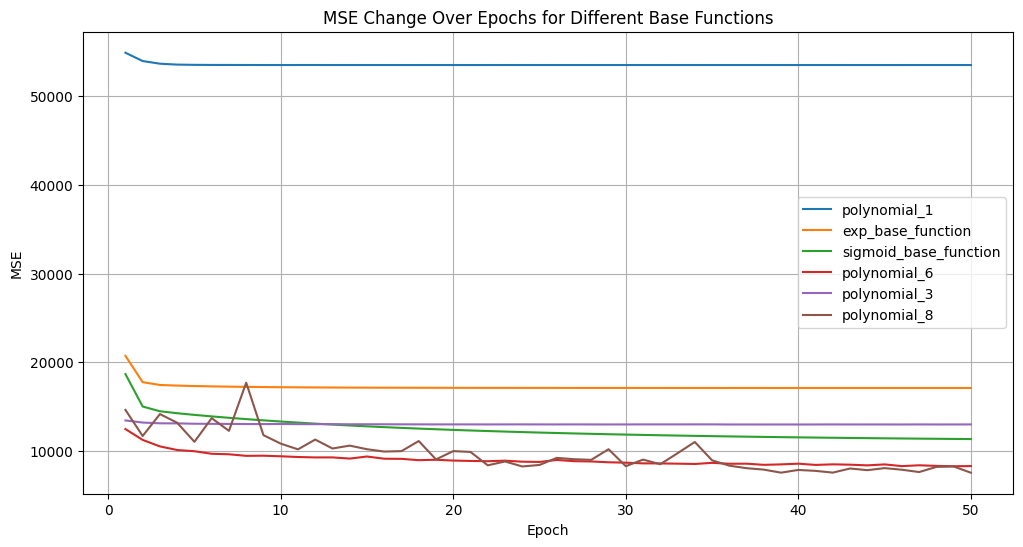

In [300]:
learning_rate = 0.001
batch_size = 16
lambda1 = 0
lambda2 = 0
epochs = 50 


base_functions_subset = [polynomial_1, exp_base_function, sigmoid_base_function, polynomial_6, polynomial_3, polynomial_8]

plt.figure(figsize=(12, 6))
for base_function in base_functions_subset:
    x_train_trans = base_function(x_train)
    x_validate_trans = base_function(x_validate)
    
    phi = np.zeros((x_train_trans.shape[1], 1))
    
    MSE_history = gradient_descent(
        x_validate_trans, y_validate, x_train_trans, y_train,
        phi, square_loss, compute_gradient,
        learning_rate, epochs, batch_size, lambda1, lambda2, 0.99, False
    )

    plt.plot(range(1, epochs+1), MSE_history, label=base_function.__name__)

plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('MSE Change Over Epochs for Different Base Functions')
plt.legend()
plt.grid(True)
plt.show()


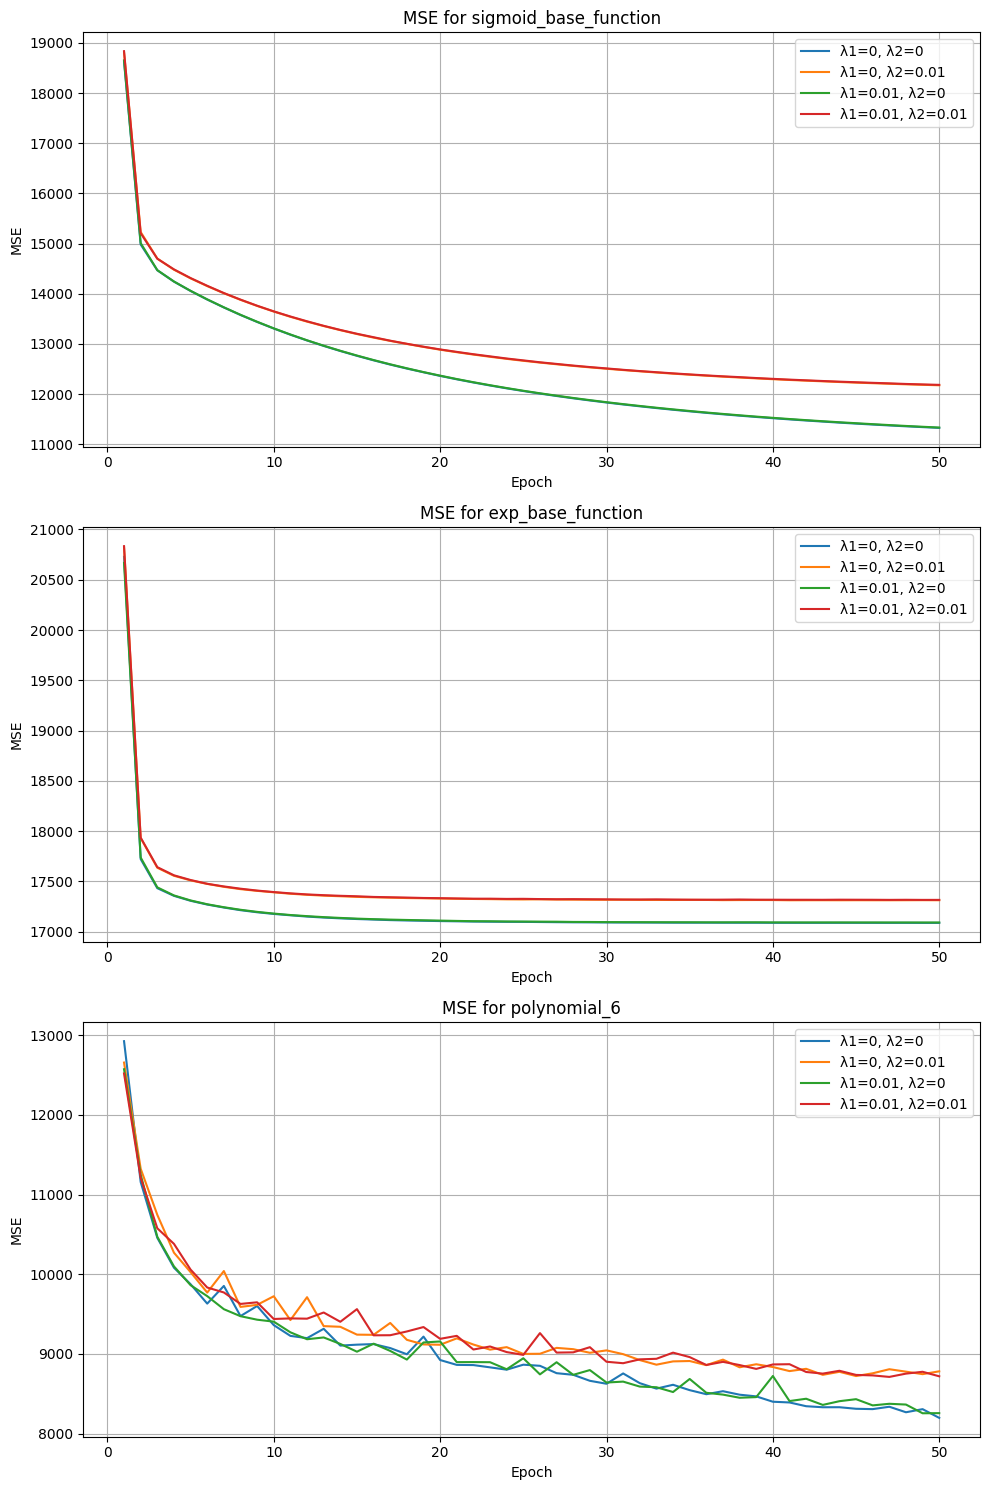

In [ ]:
learning_rate = 0.001
batch_size = 16
epochs = 50  


base_functions = [sigmoid_base_function, exp_base_function, polynomial_6]
base_functions = [sigmoid_base_function, exp_base_function, polynomial_6]
lambdas_1 = [0, 0.01]
lambdas_2 = [0, 0.01]

fig, axes = plt.subplots(3, 1, figsize=(10, 15))  
for idx, base_function in enumerate(base_functions):
    ax = axes[idx]
    for lambda1 in lambdas_1:
        for lambda2 in lambdas_2:
            x_train_trans = base_function(x_train)
            x_validate_trans = base_function(x_validate)

     
            phi = np.zeros((x_train_trans.shape[1], 1))

            MSE_history = gradient_descent(
                x_validate_trans, y_validate, x_train_trans, y_train,
                phi, square_loss, compute_gradient,
                learning_rate, epochs, batch_size, lambda1, lambda2, 0.99, False
            )

            label = f'λ1={lambda1}, λ2={lambda2}'
            ax.plot(range(1, epochs+1), MSE_history, label=label)

    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE')
    ax.set_title(f'MSE for {base_function.__name__}')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()


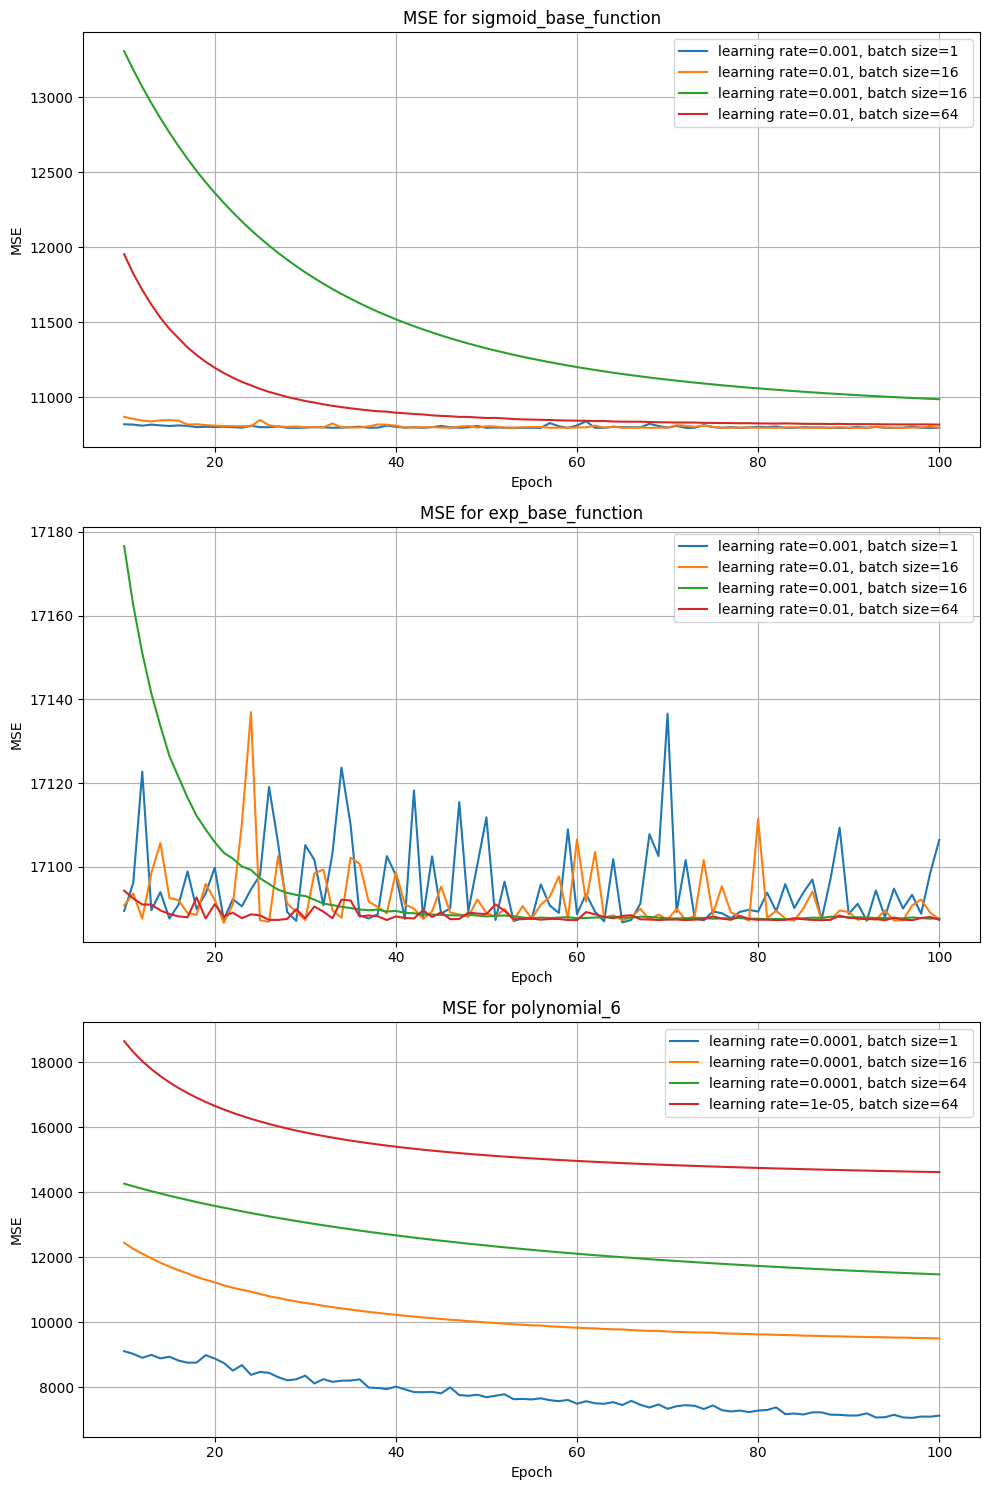

In [ ]:
lambda1 = 0
lambda2 = 0
epochs = 100  


base_functions = [sigmoid_base_function, exp_base_function, polynomial_6]
params = [[1, 0.001], [16, 0.01], [16,0.001], [64, 0.01] ]

fig, axes = plt.subplots(3, 1, figsize=(10, 15))  
for idx, base_function in enumerate(base_functions):
    if idx == 2:
        params = [[1, 0.0001], [16, 0.0001], [64, 0.0001], [64, 0.00001]]
    
    ax = axes[idx]
    for batch_size, learning_rate in params:
        x_train_trans = base_function(x_train)
        x_validate_trans = base_function(x_validate)

       
        phi = np.zeros((x_train_trans.shape[1], 1))

        MSE_history = gradient_descent(
            x_validate_trans, y_validate, x_train_trans, y_train,
            phi, square_loss, compute_gradient,
            learning_rate, epochs, batch_size, lambda1, lambda2, 0.99, False
        )

        label = f'learning rate={learning_rate}, batch size={batch_size}'
        ax.plot(range(10, epochs+1), MSE_history[9:], label=label)

    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE')
    ax.set_title(f'MSE for {base_function.__name__}')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()


# Porównanie wydajności


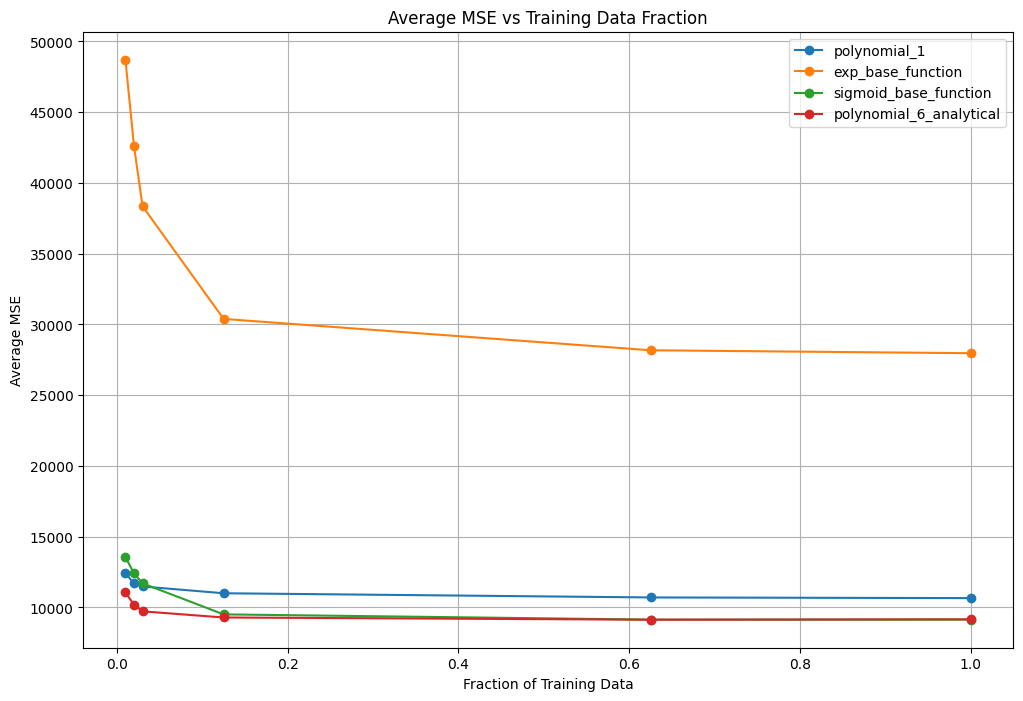

In [ ]:
num_iterations = 10
epochs = 100
fracs = [0.01, 0.02, 0.03, 0.125, 0.625, 1]
model1 = [polynomial_1, 0.00001, 1]
model2 = [exp_base_function, 0.001, 8]
model3 = [sigmoid_base_function, 0.01, 16]
model4 = [polynomial_6, 'analytical', None]  
models = [model1, model2, model3, model4]


results = [[[] for _ in fracs] for _ in models]

for iteration in range(num_iterations):

    np.random.seed(iteration)
    perm = np.random.permutation(data_size)
    data_shuffled = data[perm]

    train_size = int(0.6 * data_size)
    x_train_full = data_shuffled[:train_size, :8]
    y_train_full = data_shuffled[:train_size, 8:]
    x_validate = data_shuffled[int(train_size*5/4):, :8]
    y_validate = data_shuffled[int(train_size*5/4):, 8:]



    for model_idx, mod in enumerate(models):
        base_function, learning_rate, batch_size = mod
        for frac_idx, frac in enumerate(fracs):

            frac_size = int(frac * len(x_train_full))
            x_train_frac = x_train_full[:frac_size]
            y_train_frac = y_train_full[:frac_size]

            x_train_trans = base_function(x_train_frac)
            x_validate_trans = base_function(x_validate)

            if learning_rate == 'analytical':
                
                phi = analytical_solution(x_train_trans, y_train_frac)
                MSE_validate = square_loss(x_validate_trans, phi, y_validate, 0, 0)
                final_mse = MSE_validate[0]
            else:
           
                phi = np.zeros((x_train_trans.shape[1], 1))
                MSE_history = gradient_descent(
                    x_validate_trans, y_validate, x_train_trans, y_train_frac,
                    phi, square_loss, compute_gradient,
                    learning_rate, epochs, batch_size, 0, 0, 0.99, False
                )
                final_mse = MSE_history[-1]

            results[model_idx][frac_idx].append(final_mse)

avg_results = []
for model_idx, mod in enumerate(models):
    
    base_function, learning_rate, batch_size = mod
    if learning_rate == 'analytical':
        model_name = f"{base_function.__name__}_analytical"
    else:
        model_name = base_function.__name__
    model_avgs = []
    for frac_idx, frac in enumerate(fracs):
        avg_mse = np.mean(results[model_idx][frac_idx])
        model_avgs.append(avg_mse)
    avg_results.append((model_name, model_avgs))



plt.figure(figsize=(12, 8))
for model_name, avgs in avg_results:
    plt.plot(fracs, avgs, marker='o', label=model_name)

plt.xlabel('Fraction of Training Data')
plt.ylabel('Average MSE')
plt.title('Average MSE vs Training Data Fraction')
plt.legend()
plt.grid(True)
plt.show()
